In [1]:
import librosa
import librosa.display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

In [2]:
PROJECT_ROOT = Path("..")

metadata = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "metadata" /
    "metadata.csv"
)

sample = metadata.iloc[0]

audio_path = Path(sample["filepath"])

audio, sr = librosa.load(audio_path, sr=16000)

In [3]:
fft = np.fft.fft(audio)

In [4]:
magnitude = np.abs(fft)

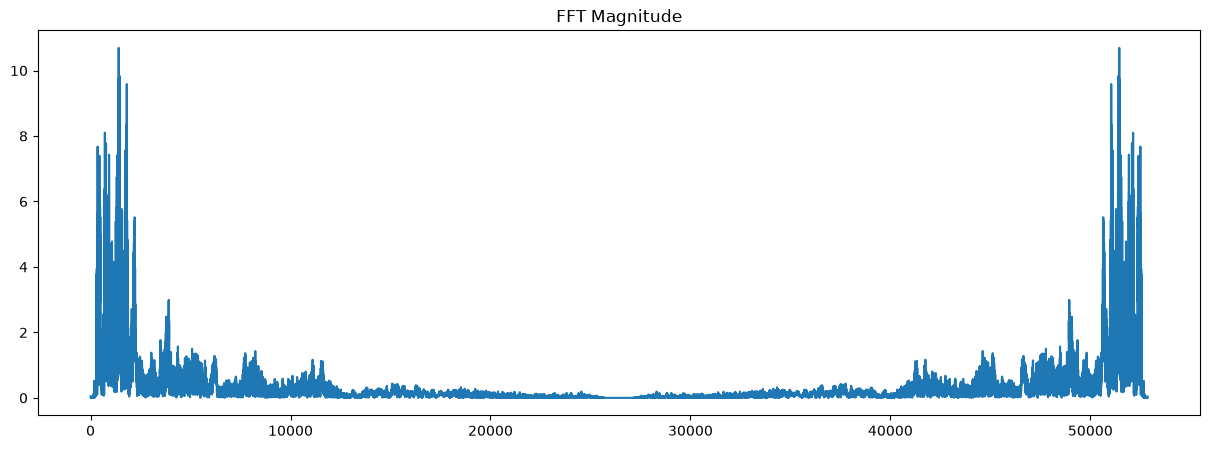

In [5]:
plt.figure(figsize=(15,5))

plt.plot(magnitude)

plt.title("FFT Magnitude")

plt.show()

In [6]:
stft = librosa.stft(audio)

In [7]:
stft_db = librosa.amplitude_to_db(
    np.abs(stft)
)

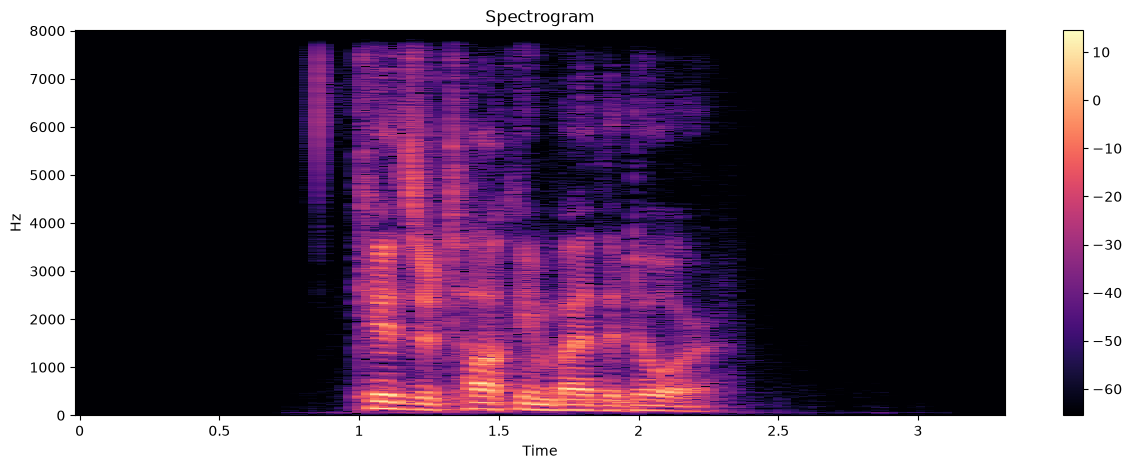

In [8]:
plt.figure(figsize=(15,5))

librosa.display.specshow(
    stft_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar()

plt.title("Spectrogram")

plt.show()

In [9]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

In [10]:
mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

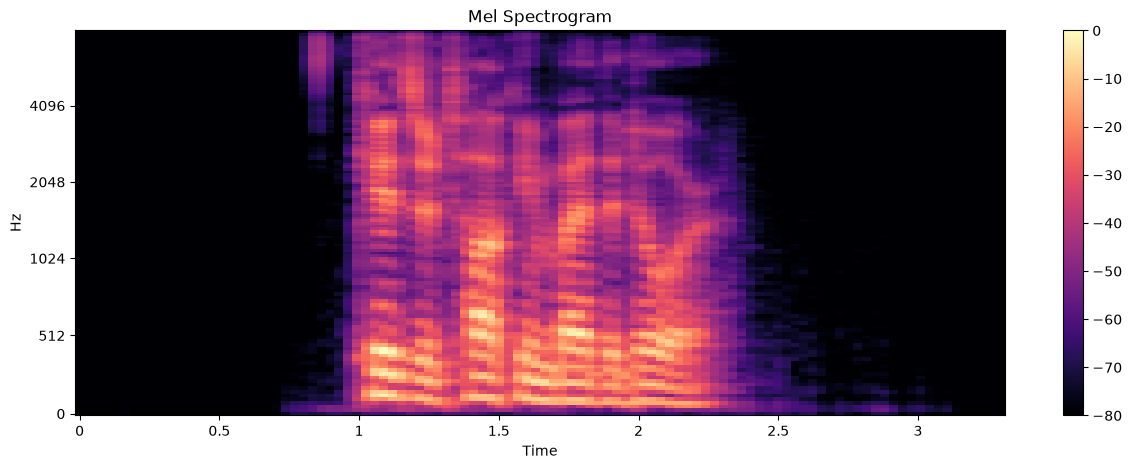

In [11]:
plt.figure(figsize=(15,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

In [12]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

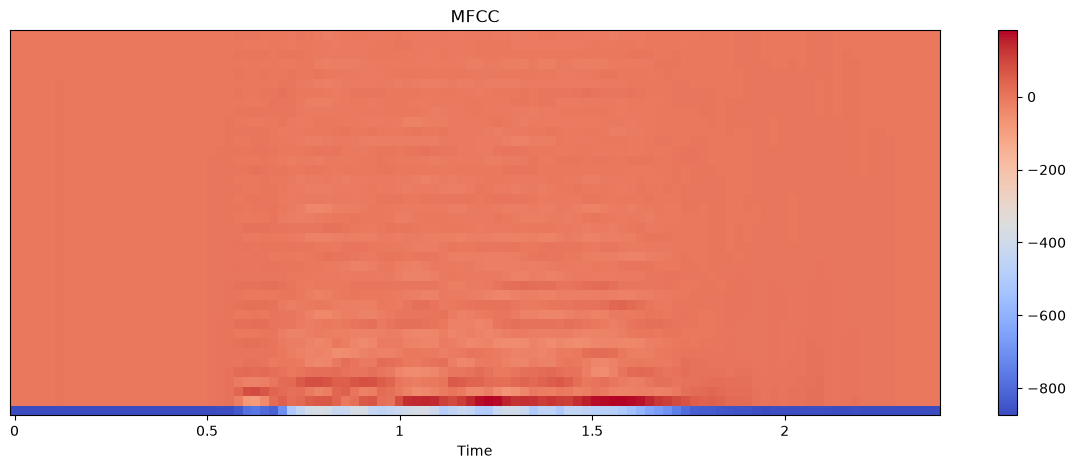

In [13]:
plt.figure(figsize=(15,5))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")

plt.show()